[ 0.          0.         -0.00074513 -0.01375621]
[-0.00074513 -0.01375621 -0.00252197 -0.02063431]
[-0.00252197 -0.02063431 -0.00464272 -0.02063431]
[-0.00464272 -0.02063431 -0.00641956 -0.01375621]
[-6.41956303e-03 -1.37562065e-02 -7.16469088e-03 -1.40462122e-16]
[-7.16469088e-03 -1.40462122e-16 -6.41956303e-03  1.37562065e-02]
[-0.00641956  0.01375621 -0.00464272  0.02063431]
[-0.00464272  0.02063431 -0.00252197  0.02063431]
[-0.00252197  0.02063431 -0.00074513  0.01375621]
[-0.00074513  0.01375621  0.          0.        ]


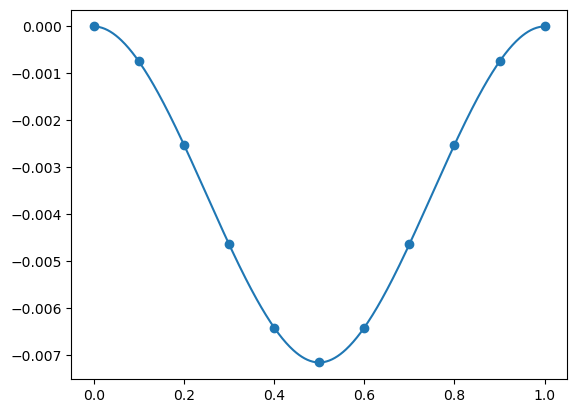

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from Scripts.beams import BeamType

def beam_interpolate_matrix(x, l):
    xi = x / l
    return np.array([1 - (3 * xi ** 2) + (2 * xi ** 3),  # N1
                     x * (1 - (2 * xi) + (xi ** 2)),  # N2
                     (3 * (xi ** 2)) - (2 * (xi ** 3)),  # N3
                     x * ((xi ** 2) - xi)])  # N4


def beam_interpolate_matrix_d1(x, l):
    xi = x / l
    return np.array([(1 / l) * (-6 * xi + 6 * xi ** 2),  # N1
                     (1 - 4 * xi + 3 * xi ** 2),  # N2
                     (1 / l) * (+6 * xi - 6 * xi ** 2),  # N3
                     x * (xi ** 2 - xi)])  # N4    


def element_stiffness_matrix(E, I, L):
    k = np.array([[12, 6 * L, -12, 6 * L],
                  [6 * L, 4 * L ** 2, -6 * L, 2 * L ** 2],
                  [-12, -6 * L, 12, -6 * L],
                  [6 * L, 2 * L ** 2, -6 * L, 4 * L ** 2]])
    return ((E * I) / L ** 3) * k




def fixed_wall_deform_calc(beam_type, element_length, element_num):
    # will be num of nodes on main
    k_size = (element_num + 1) * 2
    
    displacement_p = np.array([0,0,0,0]) # Reaction forces
    displacement_p_index = np.array([0,1, k_size-2,k_size-1]) 
    p_len = len(displacement_p)
    
    u_len = k_size - len(displacement_p)
    force_u = np.zeros(u_len)
    
    # adds the force
    force = -10 # 10N downward
    force_pos = round(element_num)-2 # midpoint   
    force_u[force_pos] = force
    
    # Creates force index from displacement index
    force_u_index = np.arange(k_size) 
    force_u_index = np.delete(force_u_index,  displacement_p_index) 
    
    assem_index = np.append(force_u_index, displacement_p_index) #2,3,4,5, ... ,0,1 
    
    ix = beam_type.cross_section_properties['second moment of area x']
    e = beam_type.material["elastic modulus"]

    global_k = np.zeros((k_size ,k_size))
    for i in range(element_num):
        global_k[i*2:i*2+4,i*2:i*2+4] += element_stiffness_matrix(e,ix,element_length)

    # copy k
    for i in displacement_p_index:
        global_k = np.concatenate((global_k,[global_k[i]]),axis=0)

    # delete old rows
    global_k = np.delete(global_k,displacement_p_index,axis=0)

    # partition k 
    K_uu = np.zeros((u_len,u_len))
    K_up = np.zeros((u_len,p_len))
    K_pu = np.zeros((p_len,u_len))
    K_pp = np.zeros((p_len,p_len))
    
    for i in range(u_len):
        global_k_index = force_u_index[i]
        K_uu[i] = global_k[0:u_len,global_k_index]
        K_up[i] = global_k[k_size-p_len:,global_k_index]

    for i in range(p_len):
        global_k_index = displacement_p_index[i]
        K_pu[i] = global_k[0:u_len,global_k_index]
        K_pp[i] = global_k[k_size-p_len:,global_k_index]
        
    K_uu_inv = np.linalg.inv(K_uu)
    
    displacement_u = K_uu_inv @ (force_u - K_up @ displacement_p)
    force_p = K_pu @ displacement_u + K_pp @ displacement_p
    
    displacement = np.append(displacement_u, displacement_p)
    force = np.append(force_u, force_p)

    displacement_refactor = np.empty(k_size)
    force_refactor = np.empty(k_size)
    
    for i in range(k_size):
        displacement_refactor[assem_index[i]] = displacement[i]
        force_refactor[assem_index[i]] = force[i]
   
    return displacement_refactor,force_refactor


def plot_deformation(Disp,L):
    y = []
    x = []
    
    for i in range(0,len(Disp)-2,2):
        x_loc = np.linspace(0, L, 50)
        element_disp = Disp[i:i+4]
        print(element_disp)
        for x_val in x_loc:
            N = beam_interpolate_matrix(x_val,L)  
            y_val = N[0] * element_disp[0] + N[1] * element_disp[1] + N[2] * element_disp[2] + N[3] * element_disp[3]
            y = np.append(y,y_val)
            x = np.append(x,x_val + (i/2)*L)
    plt.plot(x, y)
    plt.scatter(np.arange(len(Disp[::2]))*L, Disp[::2])

beam_type_1 = BeamType("annulus", [0.025, 0.0225], "Aluminum7075-T6", "type_1")

element_len = 0.1
calc_1_disp, calc_1_force = fixed_wall_deform_calc(beam_type_1, element_len, 10)
plot_deformation(calc_1_disp,element_len)

In [10]:
import numpy as np

a = np.array([[1,2],[3,4]])
b = np.array([[5,6],[7,8]])
c = np.concatenate([a,b],axis=0)
d = np.concatenate([a,b],axis=0)
print(
    np.concatenate([c,d],axis=1)
)

[[1 2 1 2]
 [3 4 3 4]
 [5 6 5 6]
 [7 8 7 8]]


In [1]:
a,b,c = 0
c += 1 
print(c + b)

TypeError: cannot unpack non-iterable int object